# Scaling Experiments Analysis

This notebook analyzes the results of the `scaling_farmers` and `scaling_intermediaries` experiments. It calculates welfare and profit metrics relative to the total fruit value, following the methodology used in the welfare analysis of Experiment 6.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Constants from Experiment 6 / figure_welfare.ipynb
FRUIT_PRICE = 2513.0
CONVERSION_FACTOR = 1000.0

def load_results(directory):
    all_results = []
    if not os.path.exists(directory):
        print(f"Directory {directory} not found.")
        return pd.DataFrame()
    
    files = [f for f in os.listdir(directory) if f.endswith(".json")]
    for filename in sorted(files, key=lambda x: int(x.split('.')[0]) if x.split('.')[0].isdigit() else x):
        with open(os.path.join(directory, filename), 'r') as f:
            try:
                data = json.load(f)
                if isinstance(data, list):
                    all_results.extend(data)
                else:
                    all_results.append(data)
            except Exception as e:
                print(f"Error loading {filename}: {e}")
    return pd.DataFrame(all_results)

def extract_metrics(df, independent_var):
    processed = []
    for _, row in df.iterrows():
        # Get quantities to calculate total value
        quantities = row.get('farmer_quantities', {})
        if not quantities:
            continue
        
        # Calculate total fruit value as the denominator
        total_fruit_value = np.sum(list(quantities.values())) * FRUIT_PRICE * CONVERSION_FACTOR
        
        # We extract metrics from 'summary_vanilla' by default
        summary = row.get('summary_vanilla', {})
        if not summary:
            continue
            
        max_sol = summary.get('max_int_welf_sol', {})
        min_sol = summary.get('min_int_welf_sol', {})
        
        # Profit from different constraint types
        prof_vanilla = row.get('summary_vanilla', {}).get('max_int_welf_sol', {}).get('profit', 0)
        prof_structured = row.get('summary_structured', {}).get('max_int_welf_sol', {}).get('profit', 0)
        prof_domination = row.get('summary_domination', {}).get('max_int_welf_sol', {}).get('profit', 0)
        
        processed.append({
            independent_var: row[independent_var],
            'profit_vanilla_perc': prof_vanilla / total_fruit_value,
            'profit_structured_perc': prof_structured / total_fruit_value,
            'profit_domination_perc': prof_domination / total_fruit_value,
            'max_farmer_welfare_perc': min_sol.get('farmer_welfare', 0) / total_fruit_value,
            'min_farmer_welfare_perc': max_sol.get('farmer_welfare', 0) / total_fruit_value,
            'max_int_welfare_perc': max_sol.get('intermediary_welfare', 0) / total_fruit_value,
            'min_int_welfare_perc': min_sol.get('intermediary_welfare', 0) / total_fruit_value,
            'instance_id': row.get('instance_id', 0)
        })
    return pd.DataFrame(processed)

## 1. Scaling Farmers Experiment
In this experiment, we vary the scale of farmer production and observe the impact on platform profit and agent welfare.

In [3]:
df_farmers_raw = load_results('../data/results_scaling_farmers')
if not df_farmers_raw.empty:
    df_farmers = extract_metrics(df_farmers_raw, 'scale_factor')
    print(f"Loaded {len(df_farmers)} results.")
    display(df_farmers.groupby('scale_factor').mean())
else:
    print("Data directory 'data/results_scaling_farmers' is empty or missing.")

Loaded 196 results.


,profit_vanilla_perc,profit_structured_perc,profit_domination_perc,max_farmer_welfare_perc,min_farmer_welfare_perc,max_int_welfare_perc,min_int_welfare_perc,instance_id
scale_factor,,,,,,,,
1.00,0.806796,0.783145,0.806687,0.097258,0.090684,0.024283,0.017710,95.5
1.05,0.786065,0.765426,0.775615,0.100348,0.087648,0.044014,0.031315,96.5
1.10,0.780721,0.731801,0.771582,0.128770,0.124034,0.016185,0.011449,97.5
1.15,0.772902,0.715780,0.768950,0.111672,0.100848,0.043827,0.033004,98.5
1.20,0.714597,0.740613,0.723540,0.200495,0.194737,0.010684,0.004927,99.5
1.25,0.722202,0.708844,0.731206,0.162198,0.148630,0.046301,0.032733,100.5
1.30,0.785851,0.829095,0.783077,0.108407,0.078404,0.056728,0.026725,94.5


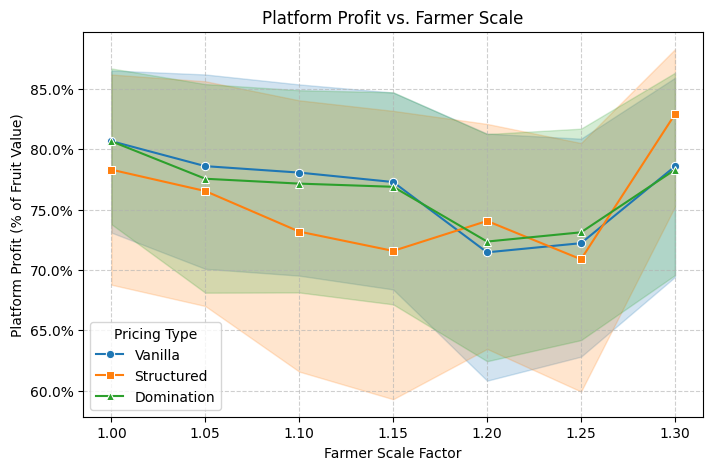

In [4]:
if not df_farmers_raw.empty:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df_farmers, x='scale_factor', y='profit_vanilla_perc', marker='o', label='Vanilla')
    sns.lineplot(data=df_farmers, x='scale_factor', y='profit_structured_perc', marker='s', label='Structured')
    sns.lineplot(data=df_farmers, x='scale_factor', y='profit_domination_perc', marker='^', label='Domination')
    
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.1f}%'))
    plt.xlabel("Farmer Scale Factor")
    plt.ylabel("Platform Profit (% of Fruit Value)")
    plt.title("Platform Profit vs. Farmer Scale")
    plt.legend(title="Pricing Type")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('farmers_profit_scaling.png', bbox_inches='tight')
    plt.show()

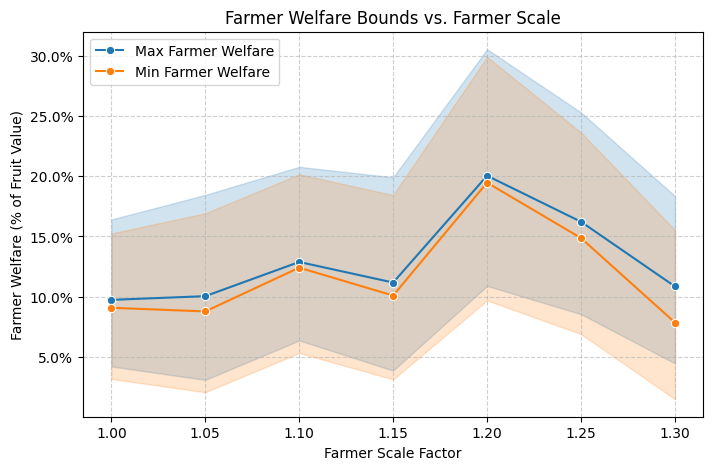

In [5]:
if not df_farmers_raw.empty:
    plt.figure(figsize=(8, 5))
    # Farmer Welfare Bounds
    sns.lineplot(data=df_farmers, x='scale_factor', y='max_farmer_welfare_perc', label='Max Farmer Welfare', marker='o')
    sns.lineplot(data=df_farmers, x='scale_factor', y='min_farmer_welfare_perc', label='Min Farmer Welfare', marker='o')
    
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.1f}%'))
    plt.xlabel("Farmer Scale Factor")
    plt.ylabel("Farmer Welfare (% of Fruit Value)")
    plt.title("Farmer Welfare Bounds vs. Farmer Scale")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('farmers_welfare_bounds.png', bbox_inches='tight')
    plt.show()

## 2. Scaling Intermediaries Experiment
In this experiment, we vary the number of intermediaries to study how increased competition affects the platform and welfare distribution.

In [6]:
df_ints_raw = load_results('../data/results_scaling_ints')
if not df_ints_raw.empty:
    df_ints = extract_metrics(df_ints_raw, 'n_ints')
    print(f"Loaded {len(df_ints)} results.")
    display(df_ints.groupby('n_ints').mean())
else:
    print("Data directory 'data/results_scaling_ints' is empty or missing.")

Loaded 196 results.


,profit_vanilla_perc,profit_structured_perc,profit_domination_perc,max_farmer_welfare_perc,min_farmer_welfare_perc,max_int_welfare_perc,min_int_welfare_perc,instance_id
n_ints,,,,,,,,
10,0.792540,0.742629,0.792540,0.113929,0.105067,0.019061,0.010199,95.5
15,0.850230,0.864333,0.847421,0.017525,0.009241,0.057762,0.049477,96.5
20,0.823103,0.764844,0.825631,0.083311,0.077650,0.023740,0.018080,97.5
25,0.800342,0.721713,0.780044,0.108013,0.099384,0.024516,0.015888,98.5
30,0.824824,0.801290,0.809856,0.082257,0.074693,0.026176,0.018612,99.5
35,0.839726,0.770078,0.837186,0.067481,0.059601,0.027352,0.019472,100.5
40,0.805306,0.667083,0.805345,0.096570,0.085620,0.035054,0.024103,94.5


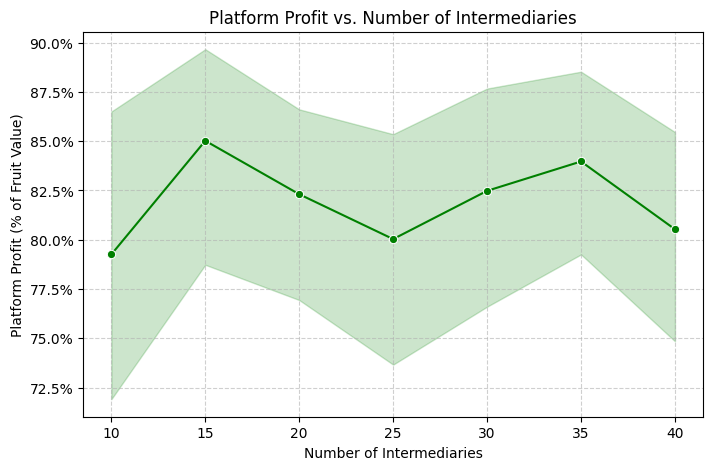

In [7]:
if not df_ints_raw.empty:
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df_ints, x='n_ints', y='profit_vanilla_perc', marker='o', color='green')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.1f}%'))
    plt.xlabel("Number of Intermediaries")
    plt.ylabel("Platform Profit (% of Fruit Value)")
    plt.title("Platform Profit vs. Number of Intermediaries")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('ints_profit_scaling.png', bbox_inches='tight')
    plt.show()

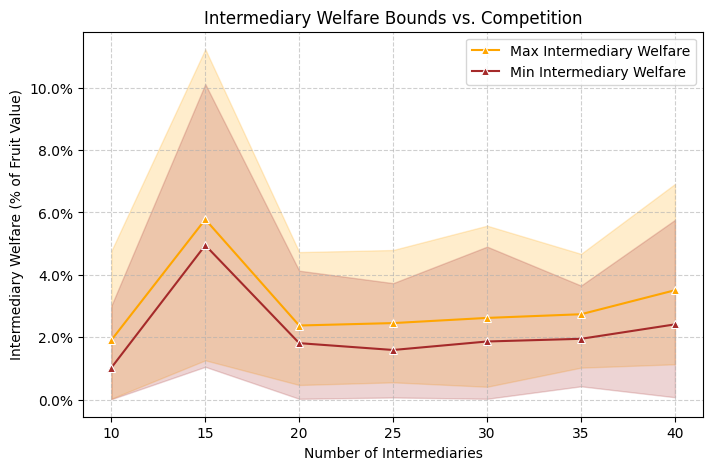

In [8]:
if not df_ints_raw.empty:
    plt.figure(figsize=(8, 5))
    # Intermediary Welfare Bounds
    sns.lineplot(data=df_ints, x='n_ints', y='max_int_welfare_perc', label='Max Intermediary Welfare', marker='^', color='orange')
    sns.lineplot(data=df_ints, x='n_ints', y='min_int_welfare_perc', label='Min Intermediary Welfare', marker='^', color='brown')
    
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.1f}%'))
    plt.xlabel("Number of Intermediaries")
    plt.ylabel("Intermediary Welfare (% of Fruit Value)")
    plt.title("Intermediary Welfare Bounds vs. Competition")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('ints_welfare_bounds.png', bbox_inches='tight')
    plt.show()